In [73]:
using Pkg
Pkg.activate(".")
using LaTeXStrings, LinearAlgebra, PsfUnmixing, Statistics, Random
using PyPlot


  Activating project at `~/PsfUnmixing`


In [74]:
function jacobian(k_0, k_1, theta, eta, dictionary, xgrid)
	d = length(dictionary[1])
	G0 = multi_block(k_0, theta, dictionary, xgrid)
	G1 = multi_block(k_1, theta, dictionary, xgrid)
	diag_eta = block_diag(collect(Iterators.partition(eta, d)))
	return hcat(G1 * diag_eta, G0)
end

jacobian (generic function with 1 method)

In [75]:
function jacobian_vp(k_0, k_1, theta, eta, dictionary, xgrid)
	d = length(dictionary[1])

	G0 = multi_block(k_0, theta, dictionary, xgrid)
	G1 = multi_block(k_1, theta, dictionary, xgrid)

	x_obs = G0 * eta

	
	diag_eta = block_diag(collect(Iterators.partition(eta, d)))
	
	grad_theta_r = G1 * diag_eta
	U, = svd(G0)

	return -grad_theta_r + U * transpose(U) * grad_theta_r 
end

jacobian_vp (generic function with 1 method)

In [76]:
function jacobian_norm(
	k_0,
	k_1,
	θ_star,
	eta_star,
	Δ,
	T,
	p,
	d,
	xgrid;
	mc_trials = 10,
	rng = MersenneTwister(0),
)
	jacobian_norms    = zeros(mc_trials)
	vp_jacobian_norms = zeros(mc_trials)
	for i in 1:mc_trials
		dictionary           = generate_spike_groups(rng, -T, T, Δ, p, d)
		J = jacobian(k_0, k_1, θ_star, eta_star, dictionary, xgrid)
		jacobian_norms[i]    = opnorm(J)
		J_vp = jacobian_vp(k_0, k_1, θ_star, eta_star, dictionary, xgrid)
		vp_jacobian_norms[i] = opnorm(J_vp)
	end
	return mean(jacobian_norms),
	std(jacobian_norms),
	mean(vp_jacobian_norms),
	std(vp_jacobian_norms)
end


jacobian_norm (generic function with 1 method)

In [77]:
function jacobian_experiment(
	k_0,
	k_1,
	theta_star,
	eta_star,
	T,
	p,
	d;
	Δ_min = 1e-3,
	Δ_max = 1e-1,
	mc_trials = 10,
	x_samples = 1000,
	sep_samples = 10,
)
	xgrid    = range(-T, T, x_samples)
	Δ       = range(Δ_min, Δ_max, sep_samples)
	means    = zeros(sep_samples)
	stds     = zeros(sep_samples)
	means_vp = zeros(sep_samples)
	stds_vp  = zeros(sep_samples)
	for (i, δ) in enumerate(Δ)
		means[i], stds[i], means_vp[i], stds_vp[i] = jacobian_norm(
			k_0,
			k_1,
			theta_star,
			eta_star,
			δ,
			T,
			p,
			d,
			xgrid;
			mc_trials = 10,
		)
	end
	return means, stds, means_vp, stds_vp
end


jacobian_experiment (generic function with 1 method)

In [78]:
function mu_local(grid, k, θ, Δ)
	return abs(dot(k(θ, grid), k(θ, grid .- Δ)))
end

function coherence_local(grid, k, θ, Δ; M = 100)
	return sum(mu_local(grid, k, θ, m * Δ) for m ∈ (-M):M)
end


coherence_local (generic function with 1 method)

In [95]:
function lipschitz_coherence(
	k,
	θ_min,
	θ_max,
	Δ,
	xgrid;
	omega_samples = 100,
	coherence_sum_samples = 10,
)
	θ_range = range(θ_min, θ_max, length = omega_samples)
	opnorms = zeros(Float64, length(θ_range))
	for (i, θ) in enumerate(θ_range)
		opnorms[i] = coherence_local(
			xgrid,
			k,
			θ,
			Δ,
			M = coherence_sum_samples,
		)
	end
	return maximum(opnorms)
end


function coherence_bound(
	k_1,
	k_0,
	theta_min,
	theta_max,
	eta_star,
	T,
	p;
	Δ_min = 1e-3,
	Δ_max = 1e-1,
	x_samples = 1_000,
	omega_samples = 10,
	sep_samples = 10,
	coherence_sum_samples = 10,
)
	xgrid = range(-T, T, x_samples)
	Δ = range(Δ_min, Δ_max, sep_samples)
	eta_norm = norm(eta_star, 2)
	result = zeros(sep_samples)
	for (i, δ) in enumerate(Δ)
		σ_0 = lipschitz_coherence(k_0, theta_min, theta_max, δ, xgrid, coherence_sum_samples = coherence_sum_samples)
		σ_1 = lipschitz_coherence(k_1, theta_min, theta_max, δ, xgrid, coherence_sum_samples = coherence_sum_samples)
		result[i] = sqrt(σ_1) * eta_norm + sqrt(p*σ_0)
	end
	return result
end


coherence_bound (generic function with 3 methods)

In [96]:
u = 2 # naturalized gaussian kernel

T = 1.0
p = 2
d = 2

s_min = 1e-3
s_max = 1e-2

θ_min = s_laplace(s_min, u, s_min)
θ_max = s_laplace(s_max, u, s_min)

k_0(θ, t) = laplace_0_n(θ, t, u, umin = s_min)
k_1(θ, t) = laplace_1_n(θ, t, u, umin = s_min)

k_0_5(θ, t) = laplace_0_n(θ, t, 5, umin = s_min)
k_1_5(θ, t) = laplace_1_n(θ, t, 5, umin = s_min)

T = 1.0

sep_samples = 100;

In [97]:
Δ_min_1 = 1e-3
Δ_max_1 = 5e-2

x_samples = 10_000

mc_trials = 200

theta_star = fill(θ_max, p)
eta_star = ones(p*d)

μ = coherence_bound(
	k_1,
	k_0,
	θ_min,
	θ_max,
	eta_star,
	T,
	p,
	Δ_min = Δ_min_1,
	Δ_max = Δ_max_1,
	x_samples = x_samples,
	sep_samples = sep_samples,
	coherence_sum_samples = d,
);

μ_5 = coherence_bound(
	k_1_5,
	k_0_5,
	θ_min,
	θ_max,
	eta_star,
	T,
	Δ_min = Δ_min_1,
	Δ_max = Δ_max_1,
	x_samples = x_samples,
	sep_samples = sep_samples,
	coherence_sum_samples = d,
);

In [98]:
 
means, stds, vp_means, vp_stds = jacobian_experiment(
	k_0,
	k_1,
	theta_star,
	eta_star,
	T,
	p,
	d,
	Δ_min = Δ_min_1,
	Δ_max = Δ_max_1,
	x_samples = x_samples,
	sep_samples = sep_samples,
	mc_trials = mc_trials,
);

means_5, stds_5, vp_means_5, vp_stds_5 = jacobian_experiment(
	k_0_5,
	k_1_5,
	theta_star,
	eta_star,
	T,
	p,
	d,
	Δ_min = Δ_min_1,
	Δ_max = Δ_max_1,
	x_samples = x_samples,
	sep_samples = sep_samples,
	mc_trials = mc_trials,
);



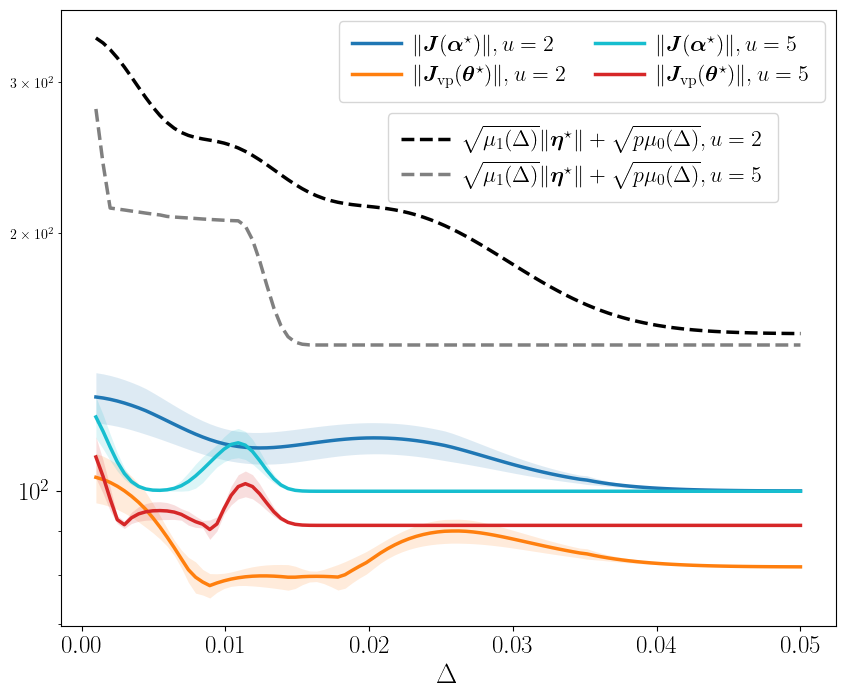

In [162]:
using PyPlot
using LaTeXStrings

PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

const mpl = PyPlot.matplotlib

to_vec(x) = collect(Float64.(x))

# Ribbon curve
function plot_band!(ax, x, mean, std; color, label)
    xv = to_vec(x)
    mv = to_vec(mean)
    sv = to_vec(std)

    ax.plot(xv, mv;
        color=color,
        linestyle="-",
        linewidth=2.5,
        label=label,
        zorder=3,
    )

    ax.fill_between(xv, mv .- sv, mv .+ sv;
        color=color,
        alpha=0.15,
        linewidth=0,
        zorder=2,
    )
end

# Dotted reference curve (separate color!)
function plot_reference!(ax, x, y; label, color)
    xv = to_vec(x)
    yv = (y isa Number) ? fill(Float64(y), length(xv)) : to_vec(y)

    ax.plot(xv, yv;
        color=color,
        linestyle="--",
        linewidth=2.5,
        label=label,
        zorder=4,
    )
end

function beautify_axes!(ax)
    ax.set_xlabel(L"\Delta", fontsize=20)

    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=18)

    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(16)

    ax.minorticks_on()
end

function pad_ylims!(ax; frac=0.06)
    ylo, yhi = ax.get_ylim()
    pad = frac * (yhi - ylo)
    ax.set_ylim(ylo - pad, yhi + pad)
end

# --------------------------------------------------

Δ_1 = collect(range(Δ_min_1, Δ_max_1; length=sep_samples))

fig, ax = subplots(figsize=(10, 8))

# ax.set_yscale("log")


plot_band!(ax, Δ_1, means, stds;
    color="tab:blue",
    label=L"\|\bm{J}(\bm{\alpha}^\star)\|, u = 2",
)

plot_band!(ax, Δ_1, vp_means, vp_stds;
    color="tab:orange",
    label=L"\|\bm{J}_{\mathrm{vp}}(\bm{\theta}^\star)\|, u = 2",
)


plot_reference!(ax, Δ_1,
    μ;
    label=L"\sqrt{\mu_1(\Delta)} \|\bm{\eta}^\star\| + \sqrt{p\mu_0(\Delta)}, u = 2",
    color="Black"
)

plot_band!(ax, Δ_1, means_5, stds_5;
    color="tab:cyan",
    label=L"\|\bm{J}(\bm{\alpha}^\star)\|, u = 5",
)

plot_band!(ax, Δ_1, vp_means_5, vp_stds_5;
    color="tab:red",
    label=L"\|\bm{J}_{\mathrm{vp}}(\bm{\theta}^\star)\|, u = 5",
)


plot_reference!(ax, Δ_1,
    μ_5;
    label=L"\sqrt{\mu_1(\Delta)} \|\bm{\eta}^\star\| + \sqrt{p\mu_0(\Delta)}, u = 5",
    color="grey"
)

# pad_ylims!(ax)

ax.set_yscale("log")
# beautify_axes!(ax)

using PyCall
const mlines = PyPlot.matplotlib.lines

handles, labels = ax.get_legend_handles_labels()

# We assume plotting order:
# 1 J2
# 2 Jvp2
# 3 th2
# 4 J5
# 5 Jvp5
# 6 th5

# --- Legend 1: empirical (2 columns, paired) ---
leg_emp = ax.legend(
    handles[[1,2,4,5]],
    labels[[1,2,4,5]],
    loc="upper right",
    ncol=2,
    fontsize=16,
    frameon=true,
    columnspacing=1.2,
    handlelength=2.2,
    handletextpad=0.6,
    borderpad=0.6,
    labelspacing=0.4,
)

# --- Legend 2: theory (stacked, narrow) ---
leg_th = ax.legend(
    handles[[3,6]],
    labels[[3,6]],
    loc="upper right",
    bbox_to_anchor=(0.94, 0.85),   # nudges it just below first legend
    fontsize=16,
    frameon=true,
    handlelength=2.2,
    handletextpad=0.6,
    borderpad=0.6,
    labelspacing=0.4,
)

ax.add_artist(leg_emp)

ax.set_xlabel(L"\Delta", fontsize=20)

ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)

fig.savefig("figures/tsp_jacobian_coherence.pdf", bbox_inches="tight", dpi=1000)

fig

In [163]:
PyPlot.close()

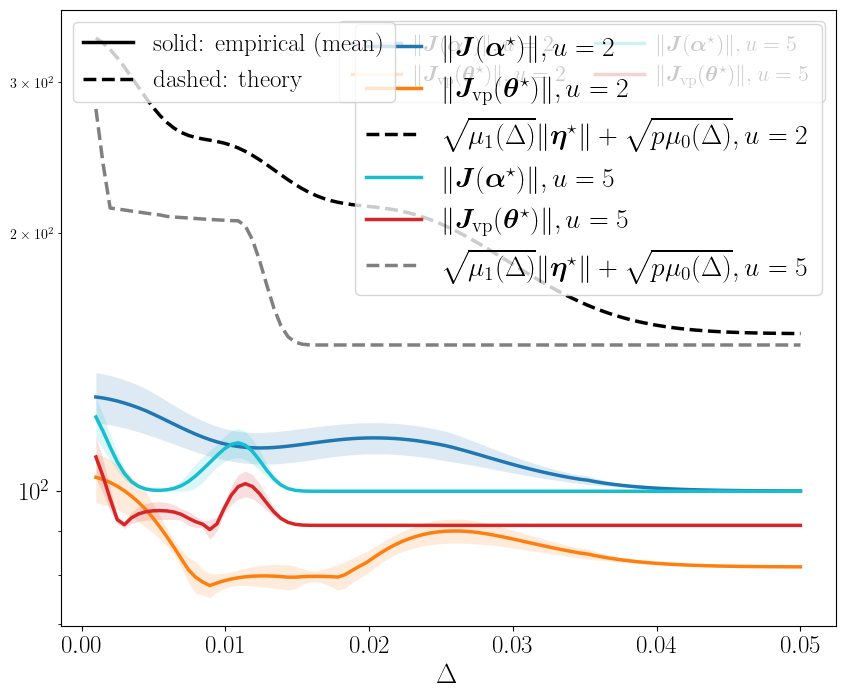

In [164]:
# --- Legends (drop-in) -------------------------------------------------------
using PyCall
const mlines = PyPlot.matplotlib.lines

# 1) Remove duplicate legend entries automatically (keeps first occurrence)
handles, labels = ax.get_legend_handles_labels()
seen = Set{String}()
uh = PyObject[]
ul = String[]
for (h, l) in zip(handles, labels)
    if !(l in seen) && l != "_nolegend_"
        push!(uh, h)
        push!(ul, l)
        push!(seen, l)
    end
end

# Legend 1: the actual labeled curves (your LaTeX labels)
leg1 = ax.legend(uh, ul, loc="upper right", fontsize=20, frameon=true)

# 2) Legend 2: style meaning via proxy artists
solid = mlines.Line2D([0.0], [0.0],
    color="black", linestyle="-", linewidth=2.5,
    label="solid: empirical (mean)"
)
dashed = mlines.Line2D([0.0], [0.0],
    color="black", linestyle="--", linewidth=2.5,
    label="dashed: theory"
)

leg2 = ax.legend(handles=[solid, dashed], loc="upper left", fontsize=18, frameon=true)

# Keep both legends visible
ax.add_artist(leg1)
# ----------------------------------------------------------------------------- 

fig